<a href="https://colab.research.google.com/github/tarumi283/tarumi/blob/main/CircadianClock_Aging_ParameterSimulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

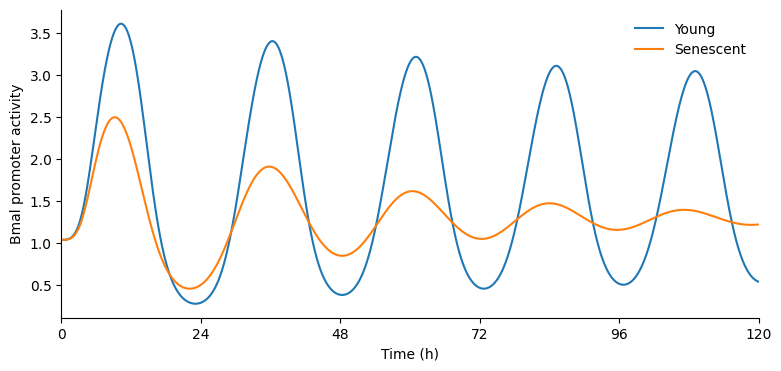

In [17]:
"""
AR2011 Mammalian Circadian Clock Model + Dexamethasone (Dex) Synchronization
- Full 19-variable AR2011 ODEs preserved
- Dex pulse entrains the clock by transiently boosting PER transcription
- Compare Young vs Senescent parameter sets
- Output: BMAL promoter activity (the BMAL mRNA transcription term)
- Plot: axes only (no top/right box), 24 h ticks, 0–120 h
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# ==============================
# Dex pulse (entrainment)
# ==============================
def dex_pulse(t, start, duration, strength):
    """Returns strength during [start, start+duration], else 0."""
    return strength if (start <= t <= start + duration) else 0.0


# ==============================
# Default parameters (AR2011)
# ==============================
def default_params():
    return {
        # Degradation
        "dx1":0.08, "dx2":0.06, "dx3":0.09,
        "dx5":0.17, "dx6":0.12, "dx7":0.15,
        "dy1":0.3, "dy2":0.2, "dy3":2.0, "dy4":0.2, "dy5":1.6,
        "dz1":0.23, "dz2":0.25, "dz3":0.6, "dz4":0.2, "dz5":0.2, "dz6":0.31, "dz7":0.3, "dz8":0.73,

        # Complex formation / dissociation
        "kfx1":2.3, "kdx1":0.01,
        "kfz4":1.0, "kfz5":1.0,
        "kdz4":1.0, "kdz5":1.0,

        # Phosphorylation / dephosphorylation
        "kfz2":2.0, "kdfz3":0.05,

        # Transcription (max)
        "V1max":1.0, "V2max":2.92, "V3max":1.90, "V4max":10.90, "V5max":1.0,

        # Transcription constants
        "kt1":3.0, "kt2":2.4, "kt3":2.07, "kt4":0.9, "kt5":8.35,
        "ki1":0.9, "ki2":0.7, "ki21":5.2, "ki3":3.3, "ki4":0.4, "ki5":1.94,

        # Translation
        "kp1":0.4, "kp2":0.26, "kp3":0.37, "kp4":0.76, "kp5":1.21,

        # Transport (import/export)
        "kiz4":0.2, "kiz5":0.1, "kiz6":0.5, "kiz7":0.1, "kiz8":0.1,
        "kex2":0.02, "kex3":0.01,

        # Fold factors / Hill coefficients
        "a":12.0, "d_":12.0,
        "g":5.0, "h":5.0, "i_":12.0,
        "b":5.0, "c":7.0,
        "e":6.0, "f":4.0, "f1":1.0,
        "v":6.0, "w":2.0,
        "p":6.0, "q":3.0,
        "n":2.0, "m":5.0,
        "a2":1.0, "a3":1.0,

        # Basal (constitutive) expression offsets
        "Rev0":0.0, "Ror0":0.0, "Bmal0":0.0, "Per0":0.0, "Cry0":0.0,

        # Time scaling
        "sf":1.07,

        # Dex entrainment parameters
        # Dex pulse: add to PER transcription multiplicatively as (1 + D)
        "dex_start":0.0,
        "dex_duration":2.0,
        "dex_strength":2.0,   # D = 2 during pulse -> PER tx multiplied by (1+2)=3
    }


# ==============================
# Full AR2011 ODEs + Dex on PER transcription
# ==============================
def clock_ar2011_dex(t, X, p):
    x = X
    dX = np.zeros(19)

    # Nuclear PER/CRY complex pool
    PC = p["a2"] * x[17] + p["a3"] * x[18]

    # Dex pulse (entrainment) -> PER transcription boost
    D = dex_pulse(t, p["dex_start"], p["dex_duration"], p["dex_strength"])

    sf = p["sf"]

    # ODEs (same structure as your original model; input flags removed; Dex added only to PER mRNA production)
    dX[0]  = sf * ( p["kfx1"] * x[9] - p["kdx1"] * x[0] - p["dx1"] * x[0] )

    dX[1]  = sf * ( p["V3max"] * (1 + p["g"] * ((x[0]/p["kt3"])**p["v"])) /
                    (1 + ((PC/p["ki3"])**p["w"]) * ((x[0]/p["kt3"])**p["v"]) + (x[0]/p["kt3"])**p["v"])
                    - p["dy3"] * x[1] )

    dX[2]  = sf * ( p["V4max"] * (1 + p["h"] * ((x[0]/p["kt4"])**p["p"])) /
                    (1 + ((PC/p["ki4"])**p["q"]) * ((x[0]/p["kt4"])**p["p"]) + (x[0]/p["kt4"])**p["p"])
                    - p["dy4"] * x[2] )

    dX[3]  = sf * ( p["kp3"] * (x[1] + p["Rev0"]) - p["kiz6"] * x[3] - p["dz6"] * x[3] )
    dX[4]  = sf * ( p["kp4"] * (x[2] + p["Ror0"]) - p["kiz7"] * x[4] - p["dz7"] * x[4] )
    dX[5]  = sf * ( p["kiz6"] * x[3] - p["dx5"] * x[5] )
    dX[6]  = sf * ( p["kiz7"] * x[4] - p["dx6"] * x[6] )

    dX[7]  = sf * ( p["V5max"] * (1 + p["i_"] * ((x[6]/p["kt5"])**p["n"])) /
                    (1 + (x[5]/p["ki5"])**p["m"] + (x[6]/p["kt5"])**p["n"])
                    - p["dy5"] * x[7] )

    dX[8]  = sf * ( p["kp5"] * (x[7] + p["Bmal0"]) - p["kiz8"] * x[8] - p["dz8"] * x[8] )
    dX[9]  = sf * ( p["kiz8"] * x[8] + p["kdx1"] * x[0] - p["kfx1"] * x[9] - p["dx7"] * x[9] )

    # PER mRNA (Dex entrainment acts here): multiply production by (1 + D)
    per_prod = p["V1max"] * (1 + p["a"] * ((x[0]/p["kt1"])**p["b"])) / \
               (1 + ((PC/p["ki1"])**p["c"]) * ((x[0]/p["kt1"])**p["b"]) + (x[0]/p["kt1"])**p["b"])
    dX[10] = sf * ( (1 + D) * per_prod - p["dy1"] * x[10] )

    dX[11] = sf * ( p["V2max"] * (1 + p["d_"] * ((x[0]/p["kt2"])**p["e"])) /
                    (1 + ((PC/p["ki2"])**p["f"]) * ((x[0]/p["kt2"])**p["e"]) + (x[0]/p["kt2"])**p["e"])
                    * (1/(1 + (x[5]/p["ki21"])**p["f1"]))
                    - p["dy2"] * x[11] )

    dX[12] = sf * ( p["kp2"] * (x[11] + p["Cry0"]) + p["kdz4"] * x[15] + p["kdz5"] * x[16]
                    - p["kfz5"] * x[12] * x[13] - p["kfz4"] * x[12] * x[14] - p["dz1"] * x[12] )

    dX[13] = sf * ( p["kp1"] * (x[10] + p["Per0"]) + p["kdz5"] * x[16] + p["kdfz3"] * x[14]
                    - p["kfz5"] * x[13] * x[12] - p["kfz2"] * x[13] - p["dz2"] * x[13] )

    dX[14] = sf * ( p["kfz2"] * x[13] + p["kdz4"] * x[15] - p["kdfz3"] * x[14]
                    - p["kfz4"] * x[14] * x[12] - p["dz3"] * x[14] )

    dX[15] = sf * ( p["kfz4"] * x[12] * x[14] + p["kex2"] * x[17] - p["kiz4"] * x[15]
                    - p["kdz4"] * x[15] - p["dz4"] * x[15] )

    dX[16] = sf * ( p["kfz5"] * x[12] * x[13] + p["kex3"] * x[18] - p["kiz5"] * x[16]
                    - p["kdz5"] * x[16] - p["dz5"] * x[16] )

    dX[17] = sf * ( p["kiz4"] * x[15] - p["kex2"] * x[17] - p["dx2"] * x[17] )
    dX[18] = sf * ( p["kiz5"] * x[16] - p["kex3"] * x[18] - p["dx3"] * x[18] )

    return dX


# ==============================
# BMAL promoter activity (reporter)
# ==============================
def bmal_promoter_activity(y, p):
    # This is the BMAL transcription production term (same as used in dX[7], without the -dy5*x[7] part)
    return p["V5max"] * (1 + p["i_"] * ((y[6]/p["kt5"])**p["n"])) / \
           (1 + (y[5]/p["ki5"])**p["m"] + (y[6]/p["kt5"])**p["n"])


# ==============================
# Simulation wrapper
# ==============================
def run_sim(p, t_end=120.0, n_points=2400):
    t_eval = np.linspace(0, t_end, n_points)
    X0 = np.full(19, 0.5)
    X0[0] = 1.0  # CLOCK/BMAL initial

    sol = solve_ivp(
        fun=clock_ar2011_dex,
        t_span=(0, t_end),
        y0=X0,
        t_eval=t_eval,
        args=(p,),
        method="RK45",
        rtol=1e-6,
        atol=1e-9
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.t, sol.y


# ==============================
# Young vs Senescent parameter sets
# ==============================
young = default_params()
sen = default_params()

# --- Dex synchronization settings ---
# Typical: Dex pulse at the beginning, then washout; model implements washout automatically (pulse ends)
young["dex_start"] = 0.0
young["dex_duration"] = 2.0
young["dex_strength"] = 2.0

sen["dex_start"] = 0.0
sen["dex_duration"] = 2.0
sen["dex_strength"] = 2.0  # change if you want weaker entrainment in senescence

# --- Aging edits (EDIT FREELY) ---
# (Put your senescence hypotheses here; start with mild changes)


# ---- 恒常発現（basal expression）----
sen["Rev0"]  = 0.5
sen["Ror0"]  = 0.0
sen["Bmal0"] = 0.0
sen["Per0"]  = 0.0
sen["Cry0"]  = 0.0

# ---- 分解速度 ----
sen["dx1"] = 0.08
sen["dx2"] = 0.06
sen["dx3"] = 0.09
sen["dx5"] = 0.17
sen["dx6"] = 0.12
sen["dx7"] = 0.15

sen["dy1"] = 0.3
sen["dy2"] = 0.2
sen["dy3"] = 2
sen["dy4"] = 0.2
sen["dy5"] = 1.6

sen["dz1"] = 0.23
sen["dz2"] = 0.25
sen["dz3"] = 0.6
sen["dz4"] = 0.2
sen["dz5"] = 0.2
sen["dz6"] = 0.31
sen["dz7"] = 0.3
sen["dz8"] = 0.73

# ---- 複合体形成・解離 ----
sen["kfx1"] = 2.3
sen["kdx1"] = 0.01
sen["kfz4"] = 1
sen["kfz5"] = 1
sen["kdz4"] = 1
sen["kdz5"] = 1

# ---- リン酸化系 ----
sen["kfz2"]  = 2
sen["kdfz3"] = 0.05

# ---- 転写最大速度 ----
sen["V1max"] = 1
sen["V2max"] = 2.92
sen["V3max"] = 1.90
sen["V4max"] = 10.90
sen["V5max"] = 1

# ---- 転写定数 ----
sen["kt1"] = 3
sen["kt2"] = 2.4
sen["kt3"] = 2.07
sen["kt4"] = 0.9
sen["kt5"] = 8.35

sen["ki1"]  = 0.9
sen["ki2"]  = 0.7
sen["ki21"] = 5.2
sen["ki3"]  = 3.3
sen["ki4"]  = 0.4
sen["ki5"]  = 1.94

# ---- 翻訳速度 ----
sen["kp1"] = 0.4
sen["kp2"] = 0.26
sen["kp3"] = 0.37
sen["kp4"] = 0.76
sen["kp5"] = 1.21

# ---- 核輸送 ----
sen["kiz4"] = 0.2
sen["kiz5"] = 0.1
sen["kiz6"] = 0.5
sen["kiz7"] = 0.1
sen["kiz8"] = 0.1

sen["kex2"] = 0.02
sen["kex3"] = 0.01

# ---- Hill係数 ----
sen["a"] = 12
sen["d"] = 12
sen["g"] = 5
sen["h"] = 5
sen["i"] = 12

sen["b"]  = 5
sen["c"]  = 7
sen["e"]  = 6
sen["f"]  = 4
sen["f1"] = 1

sen["v"] = 6
sen["w"] = 2
sen["p"] = 6
sen["q"] = 3
sen["n"] = 2
sen["m"] = 5


# ==============================
# Run
# ==============================
tY, yY = run_sim(young, t_end=120.0)
tS, yS = run_sim(sen,   t_end=120.0)

lucY = bmal_promoter_activity(yY, young)
lucS = bmal_promoter_activity(yS, sen)


# ==============================
# Plot (axes only, 24 h ticks)
# ==============================
plt.figure(figsize=(9,4))
ax = plt.gca()

plt.plot(tY, lucY, label="Young")
plt.plot(tS, lucS, label="Senescent")

plt.xlabel("Time (h)")
plt.ylabel("Bmal promoter activity")

plt.xlim(0, 120)
plt.xticks(np.arange(0, 121, 24))

# remove non-axis lines (box)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.legend(frameon=False)
plt.show()
